In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# RL & Control Libraries
import gymnasium as gym
from gymnasium import spaces
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random

from stable_baselines3 import PPO, DQN
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import EvalCallback

print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

Device: cpu


## LOAD DATA

In [ ]:
# Load prices, returns, regimes, and cointegration info
try:
    prices = pd.read_csv('pharma_prices.csv', index_col=0, parse_dates=True)
    returns = pd.read_csv('pharma_returns.csv', index_col=0, parse_dates=True)
    node_features = pd.read_csv('node_features.csv', index_col=0)
    strong_pairs_df = pd.read_csv('strong_pairs.csv')
    hmm_regimes = pd.read_csv('hmm_regimes.csv', index_col=0, parse_dates=True)

    print("✓ All CSV files loaded successfully")
except FileNotFoundError as e:
    print(f"❌ ERROR: {e}")
    print("Make sure you ran Notebook 1 and Notebook 2 first!")
    raise

# Load HMM model components
try:
    hmm_means = np.load('hmm_model_means.npy')
    hmm_transmat = np.load('hmm_model_transmat.npy')
    hmm_startprob = np.load('hmm_model_startprob.npy')
    print("✓ HMM model components loaded")
except FileNotFoundError:
    print("⚠ HMM model files not found - will proceed with regime data only")

# Load scaler
import pickle
try:
    with open('hmm_scaler.pkl', 'rb') as f:
        hmm_scaler = pickle.load(f)
    print("✓ HMM scaler loaded")
except FileNotFoundError:
    print("⚠ HMM scaler not found")

print(f"\n✓ Loaded prices: {prices.shape}")
print(f"✓ Loaded returns: {returns.shape}")
print(f"✓ Loaded HMM regimes: {hmm_regimes.shape}")
print(f"✓ Found {len(strong_pairs_df)} cointegrated pairs")

✓ All CSV files loaded successfully
✓ HMM model components loaded
✓ HMM scaler loaded

✓ Loaded prices: (1467, 39)
✓ Loaded returns: (1466, 39)
✓ Loaded HMM regimes: (1407, 6)
✓ Found 36 cointegrated pairs


In [ ]:
valid_pairs = []

for idx, row in strong_pairs_df.iterrows():
    ticker1 = str(row['Ticker1']).strip()
    ticker2 = str(row['Ticker2']).strip()
    p_value = row['P_Value']

    # Verify both tickers exist in price data
    if ticker1 in prices.columns and ticker2 in prices.columns:
        valid_pairs.append({
            'Ticker1': ticker1,
            'Ticker2': ticker2,
            'P_Value': p_value
        })

valid_pairs_df = pd.DataFrame(valid_pairs)

print(f"\n✓ Valid pairs found: {len(valid_pairs_df)}")
if len(valid_pairs_df) > 0:
    print(f"\nTop 5 pairs for training:")
    print(valid_pairs_df.head())
else:
    print("\n❌ ERROR: No valid pairs found!")
    print("Check that Notebook 1 identified cointegrated pairs.")
    raise ValueError("No valid pairs in dataset")

# Select the first valid pair for training
first_pair = valid_pairs_df.iloc[0]
ticker1 = first_pair['Ticker1']
ticker2 = first_pair['Ticker2']
p_value = first_pair['P_Value']
print(f"\n✓ Selected training pair: {ticker1}-{ticker2}")
print(f"  P-Value: {p_value:.6f}")


✓ Valid pairs found: 36

Top 5 pairs for training:
  Ticker1 Ticker2   P_Value
0    AMGN     LLY  0.000179
1    CRSP    DRIO  0.000877
2    DRIO    RARE  0.000952
3    CRSP    RARE  0.001082
4    DRIO    NVAX  0.001758

✓ Selected training pair: AMGN-LLY
  P-Value: 0.000179


## CUSTOM GYM ENVIRONMENT FOR PAIRS TRADING

In [ ]:
class PairsTradingEnv(gym.Env):
    """
    Custom Gym environment for pairs trading with RL agent.

    State Space:
        - Normalized spread (Z-score)
        - Spread velocity (rate of change)
        - Regime indicator (0=Calm, 1=Normal, 2=Volatile)
        - Current position (-1, 0, +1)
        - Unrealized PnL (normalized)

    Action Space:
        - 0: HOLD (no action)
        - 1: ENTER LONG SPREAD (long ticker1, short ticker2)
        - 2: ENTER SHORT SPREAD (short ticker1, long ticker2)
        - 3: CLOSE POSITION
    """

    def __init__(self,
                 ticker1, ticker2,
                 prices_df, returns_df, regimes_df,
                 train_start_idx=0, train_end_idx=1000,
                 transaction_cost=0.001,
                 initial_capital=10000,
                 lookback_window=20):

        super(PairsTradingEnv, self).__init__()

        self.ticker1 = ticker1
        self.ticker2 = ticker2
        self.prices_df = prices_df
        self.returns_df = returns_df
        self.regimes_df = regimes_df

        self.train_start = train_start_idx
        self.train_end = train_end_idx
        self.transaction_cost = transaction_cost
        self.initial_capital = initial_capital
        self.lookback = lookback_window

        # Action space: {HOLD, LONG, SHORT, CLOSE}
        self.action_space = spaces.Discrete(4)

        # Observation space: [spread_zscore, velocity, regime, position, pnl]
        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(5,),
            dtype=np.float32
        )

        # Current state
        self.current_step = self.train_start
        self.position = 0  # -1: short spread, 0: no position, 1: long spread
        self.entry_price = 0
        self.entry_step = 0
        self.cumulative_reward = 0
        self.trades_log = []

        print(f"✓ Environment initialized for {ticker1}-{ticker2}")
        print(f"  Training period: {train_start_idx} to {train_end_idx} days")
        print(f"  Initial capital: ${initial_capital:,.2f}")

    def _compute_spread(self, step):
        """Compute the normalized spread between ticker1 and ticker2"""
        if step >= len(self.prices_df):
            step = len(self.prices_df) - 1

        p1 = self.prices_df[self.ticker1].iloc[step]
        p2 = self.prices_df[self.ticker2].iloc[step]

        # Normalized spread using z-scores
        p1_mean = self.prices_df[self.ticker1].iloc[max(0, step-60):step].mean()
        p1_std = self.prices_df[self.ticker1].iloc[max(0, step-60):step].std()
        p2_mean = self.prices_df[self.ticker2].iloc[max(0, step-60):step].mean()
        p2_std = self.prices_df[self.ticker2].iloc[max(0, step-60):step].std()

        if p1_std == 0 or p2_std == 0:
            return 0

        spread = ((p1 - p1_mean) / p1_std) - ((p2 - p2_mean) / p2_std)
        return spread

    def _compute_spread_velocity(self, step):
        """Compute rate of change of spread"""
        if step < self.lookback:
            return 0
        spread_now = self._compute_spread(step)
        spread_past = self._compute_spread(step - self.lookback)
        return (spread_now - spread_past) / self.lookback

    def _get_regime(self, step):
        """Get current regime (0=Calm, 1=Normal, 2=Volatile)"""
        if step < len(self.regimes_df):
            return int(self.regimes_df['State'].iloc[step])
        return 1  # Default to Normal

    def _get_observation(self):
        """Get current observation"""
        spread_zscore = self._compute_spread(self.current_step)
        spread_velocity = self._compute_spread_velocity(self.current_step)
        regime = self._get_regime(self.current_step)

        # Unrealized PnL
        if self.position == 0:
            unrealized_pnl = 0
        else:
            current_spread = self._compute_spread(self.current_step)
            unrealized_pnl = self.position * (current_spread - self.entry_price)

        observation = np.array([
            spread_zscore,
            spread_velocity,
            regime,
            self.position,
            unrealized_pnl
        ], dtype=np.float32)

        return observation

    def _calculate_reward(self, action):
        """
        Reward function with regime awareness
        """
        reward = 0
        regime = self._get_regime(self.current_step)

        # 1. HOLD (Action 0)
        if action == 0:
            if self.position != 0:
                # Holding a position: Mark-to-Market PnL (Unrealized)
                current_spread = self._compute_spread(self.current_step)
                prev_spread = self._compute_spread(self.current_step - 1)

                # Did the spread move in our favor?
                step_pnl = self.position * (current_spread - prev_spread)
                reward += step_pnl * 10  # Scale up signal

                # Small penalty for holding too long (time decay)
                reward -= 0.01
            else:
                # Holding NO position: Small penalty to discourage inaction
                reward -= 0.05

        # 2. ENTER (Action 1 or 2)
        elif action == 1 or action == 2:
            if self.position == 0:
                spread = self._compute_spread(self.current_step)
                # Big reward for entering at good Z-scores (>1.5 or <-1.5)
                if abs(spread) > 1.5:
                    reward += 2.0  # Explicit reward for valid entry

                # Reduced transaction cost penalty (don't scare the agent)
                reward -= (self.transaction_cost * 10)

        # 3. CLOSE (Action 3)
        elif action == 3:
            if self.position != 0:
                current_spread = self._compute_spread(self.current_step)
                realized_pnl = self.position * (current_spread - self.entry_price)

                # Big reward for profitable exit
                if realized_pnl > 0:
                    reward += (realized_pnl * 50) + 5.0
                else:
                    reward += (realized_pnl * 50) - 1.0

                self.trades_log.append({
                    'entry_step': self.entry_step,
                    'exit_step': self.current_step,
                    'position': self.position,
                    'entry_spread': self.entry_price,
                    'exit_spread': current_spread,
                    'realized_pnl': realized_pnl
                })

        return reward

    def step(self, action):
        """Execute one step in the environment"""
        reward = self._calculate_reward(action)

        # Update position based on action
        if action == 1 and self.position == 0:  # ENTER LONG
            self.position = 1
            self.entry_price = self._compute_spread(self.current_step)
            self.entry_step = self.current_step

        elif action == 2 and self.position == 0:  # ENTER SHORT
            self.position = -1
            self.entry_price = self._compute_spread(self.current_step)
            self.entry_step = self.current_step

        elif action == 3:  # CLOSE position
            self.position = 0
            self.entry_price = 0

        # Move to next step
        self.current_step += 1
        self.cumulative_reward += reward

        # Check if episode is done
        done = self.current_step >= self.train_end

        # Get next observation
        observation = self._get_observation()

        return observation, reward, done, False, {'cumulative_reward': self.cumulative_reward}

    def reset(self, seed=None):
        """Reset environment"""
        super().reset(seed=seed)
        self.current_step = self.train_start + random.randint(0, max(1, 50))
        self.position = 0
        self.entry_price = 0
        self.cumulative_reward = 0
        self.trades_log = []

        return self._get_observation(), {}

    def render(self):
        """Render environment state"""
        pass

## SETUP TRAINING

In [ ]:
# Split data: 60% train, 20% validation, 20% test
n_samples = len(prices)
train_end = int(n_samples * 0.6)
val_end = int(n_samples * 0.8)

print(f"Data split:")
print(f"  Train: 0 to {train_end} ({train_end/n_samples*100:.1f}%)")
print(f"  Val:   {train_end} to {val_end} ({(val_end-train_end)/n_samples*100:.1f}%)")
print(f"  Test:  {val_end} to {n_samples} ({(n_samples-val_end)/n_samples*100:.1f}%)")

# Create environment factory
def make_env(ticker1, ticker2, start_idx, end_idx, env_id=0):
    """Factory function to create environments"""
    def _init():
        env = PairsTradingEnv(
            ticker1, ticker2,
            prices, returns, hmm_regimes,
            train_start_idx=start_idx,
            train_end_idx=end_idx,
            transaction_cost=0.001,
            initial_capital=10000,
            lookback_window=20
        )
        return env
    return _init

# Dictionary to store all models and results
trained_models = {}
pair_results = []

Data split:
  Train: 0 to 880 (60.0%)
  Val:   880 to 1173 (20.0%)
  Test:  1173 to 1467 (20.0%)


## TRAINING RL AGENTS

In [ ]:
# Train on each pair
for pair_idx, (idx, row) in enumerate(valid_pairs_df.iterrows()):
    ticker1 = row['Ticker1']
    ticker2 = row['Ticker2']
    p_value = row['P_Value']

    pair_name = f"{ticker1}-{ticker2}"
    print(f"\n{'='*70}")
    print(f"PAIR {pair_idx + 1}/{len(valid_pairs_df)}: {pair_name}")
    print(f"Cointegration p-value: {p_value:.6f}")
    print(f"{'='*70}")

    try:
        # Create training environment
        train_env = DummyVecEnv([
            make_env(ticker1, ticker2, 50, train_end, 0)
        ])

        # Create validation environment
        eval_env = DummyVecEnv([
            make_env(ticker1, ticker2, train_end, val_end, 1)
        ])

        # Configure PPO
        policy_kwargs = dict(
            net_arch=[128, 128],
            activation_fn=nn.ReLU
        )

        # Create model
        model = PPO(
            'MlpPolicy',
            train_env,
            learning_rate=0.0005,      # Higher LR
            n_steps=2048,
            batch_size=128,            # Larger batch
            n_epochs=10,
            gamma=0.95,                # Lower gamma (focus on immediate rewards)
            gae_lambda=0.95,
            clip_range=0.2,
            ent_coef=0.05,             # HIGHER ENTROPY (Force exploration)
            verbose=0,
            policy_kwargs=policy_kwargs,
            device='auto'
        )

        # Callback for validation
        eval_callback = EvalCallback(
            eval_env,
            best_model_save_path=f'./models/{pair_name}/',
            log_path=f'./logs/{pair_name}/',
            eval_freq=5000,
            n_eval_episodes=5,
            deterministic=True,
            render=False
        )

        print(f"Training PPO agent on {pair_name}...")

        # Train the model
        total_timesteps = 50000
        model.learn(
            total_timesteps=total_timesteps,
            callback=eval_callback,
            progress_bar=True
        )

        # Save final model
        model.save(f'ppo_model_{pair_name}')
        print(f"✓ Model saved: ppo_model_{pair_name}.zip")

        print(f"\nEvaluating {pair_name} on test set...")

        # Load best model
        try:
            best_model = PPO.load(f'./models/{pair_name}/best_model.zip')
        except FileNotFoundError:
            print(f"⚠ Best model not found, using final model")
            best_model = model

        # Create test environment
        test_env = PairsTradingEnv(
            ticker1, ticker2,
            prices, returns, hmm_regimes,
            train_start_idx=val_end,
            train_end_idx=len(prices),
            transaction_cost=0.001,
            initial_capital=10000,
            lookback_window=20
        )

        # Run agent on test set
        obs, _ = test_env.reset()
        total_reward = 0
        done = False
        step_count = 0

        while not done:
            action, _ = best_model.predict(obs, deterministic=True)
            obs, reward, done, _, info = test_env.step(action)
            total_reward += reward
            step_count += 1

        # Extract trade details
        trades_log = test_env.trades_log

        if len(trades_log) > 0:
            trades_df = pd.DataFrame(trades_log)
            win_rate = (trades_df['realized_pnl'] > 0).sum() / len(trades_df) * 100
            avg_pnl = trades_df['realized_pnl'].mean()
            total_pnl = trades_df['realized_pnl'].sum()
            num_trades = len(trades_df)
        else:
            win_rate = 0
            avg_pnl = 0
            total_pnl = 0
            num_trades = 0

        # Store results
        result = {
            'Pair': pair_name,
            'Ticker1': ticker1,
            'Ticker2': ticker2,
            'P_Value': p_value,
            'Steps': step_count,
            'Total_Trades': num_trades,
            'Cumulative_Reward': total_reward,
            'Avg_Reward_Per_Step': total_reward / step_count if step_count > 0 else 0,
            'Win_Rate': win_rate,
            'Avg_PnL_Per_Trade': avg_pnl,
            'Total_Realized_PnL': total_pnl,
        }

        pair_results.append(result)
        trained_models[pair_name] = best_model

        print(f"\n✓ {pair_name} Results:")
        print(f"  Total trades: {num_trades}")
        print(f"  Win rate: {win_rate:.1f}%")
        print(f"  Total PnL: ${total_pnl:.4f}")
        print(f"  Cumulative reward: {total_reward:.2f}")

    except Exception as e:
        print(f"❌ Error training {pair_name}: {str(e)}")
        continue

print(f"\n{'='*70}")
print(f"TRAINING COMPLETE")


PAIR 1/36: AMGN-LLY
Cointegration p-value: 0.000179
✓ Environment initialized for AMGN-LLY
  Training period: 50 to 880 days
  Initial capital: $10,000.00
✓ Environment initialized for AMGN-LLY
  Training period: 880 to 1173 days
  Initial capital: $10,000.00


Output()

Training PPO agent on AMGN-LLY...


Eval num_timesteps=5000, episode_reward=0.00 +/- 0.00

Episode length: 279.40 +/- 10.67

...

Eval num_timesteps=45000, episode_reward=1247.08 +/- 74.47

Episode length: 260.80 +/- 9.39

Eval num_timesteps=50000, episode_reward=1192.41 +/- 102.44

Episode length: 250.20 +/- 6.79

✓ Model saved: ppo_model_CRSP-VRTX.zip

Evaluating CRSP-VRTX on test set...
✓ Environment initialized for CRSP-VRTX
  Training period: 1173 to 1467 days
  Initial capital: $10,000.00

✓ CRSP-VRTX Results:
  Total trades: 24
  Win rate: 95.8%
  Total PnL: $27.1511
  Cumulative reward: 1483.30

TRAINING COMPLETE


In [ ]:
# Create results dataframe
results_df = pd.DataFrame(pair_results)
results_df = results_df.sort_values('Total_Realized_PnL', ascending=False)

print(f"\nOVERALL RESULTS (Sorted by Total PnL):")
print(results_df)

# Save results
results_df.to_csv('all_pairs_results.csv', index=False)
print(f"\n✓ Results saved to: all_pairs_results.csv")


OVERALL RESULTS (Sorted by Total PnL):
         Pair Ticker1 Ticker2   P_Value  Steps  Total_Trades  \
22  BNTX-RGEN    BNTX    RGEN  0.032725    289            52   
14  DRIO-XRAY    DRIO    XRAY  0.014593    253            31   
5   DRIO-SDGR    DRIO    SDGR  0.005434    290            40   
31  EXAS-RARE    EXAS    RARE  0.043877    273            31   
8   CRSP-NVAX    CRSP    NVAX  0.005952    277            52   
32  ENTA-VRTX    ENTA    VRTX  0.046602    281            27   
27  TMDX-VRTX    TMDX    VRTX  0.039249    291            24   
35  CRSP-VRTX    CRSP    VRTX  0.048818    271            24   
2   DRIO-RARE    DRIO    RARE  0.000952    245            14   
0    AMGN-LLY    AMGN     LLY  0.000179    279            32   
16  NVAX-RARE    NVAX    RARE  0.018135    293            35   
28  AMGN-ENTA    AMGN    ENTA  0.040342    274            28   
23  NVAX-VRTX    NVAX    VRTX  0.033957    253            21   
12  MRNA-RGEN    MRNA    RGEN  0.013200    265            26   


## COMPARE PERFORMANCE ACROSS ALL PAIRS

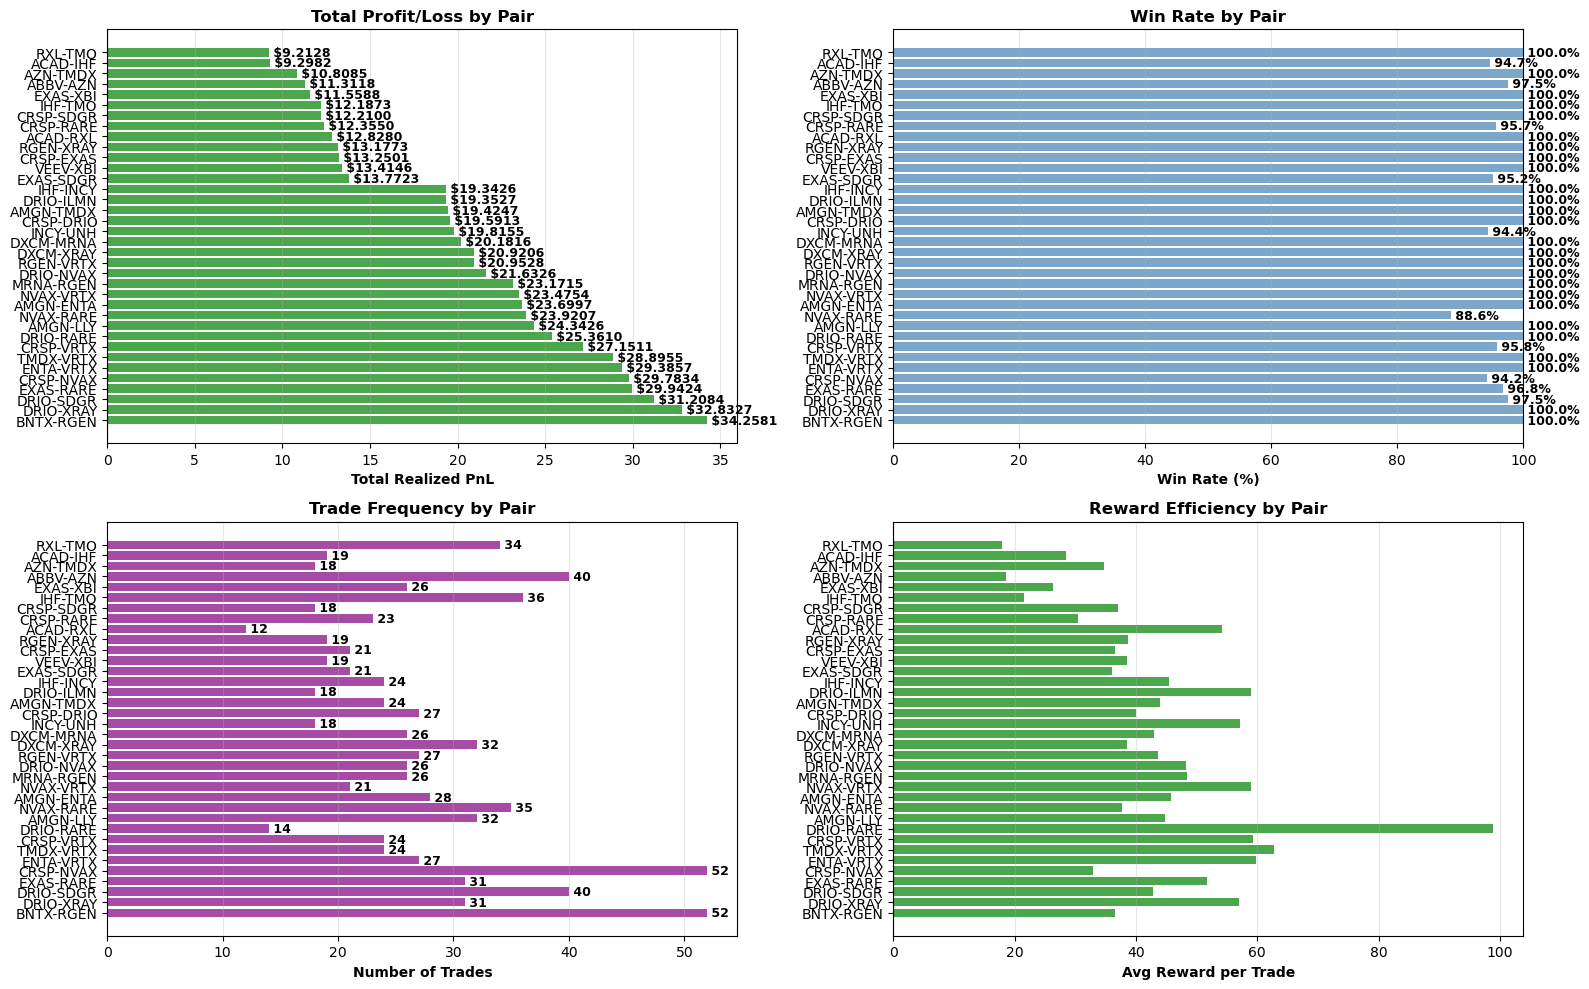

In [ ]:
# Create comprehensive comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Total PnL by Pair
ax = axes[0, 0]
colors = ['green' if pnl > 0 else 'red' for pnl in results_df['Total_Realized_PnL']]
bars = ax.barh(results_df['Pair'], results_df['Total_Realized_PnL'], color=colors, alpha=0.7)
ax.set_xlabel('Total Realized PnL', fontweight='bold')
ax.set_title('Total Profit/Loss by Pair', fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, results_df['Total_Realized_PnL'])):
    ax.text(val, bar.get_y() + bar.get_height()/2, f' ${val:.4f}',
           va='center', fontweight='bold', fontsize=9)

# Plot 2: Win Rate by Pair
ax = axes[0, 1]
bars = ax.barh(results_df['Pair'], results_df['Win_Rate'], color='steelblue', alpha=0.7)
ax.set_xlabel('Win Rate (%)', fontweight='bold')
ax.set_title('Win Rate by Pair', fontsize=12, fontweight='bold')
ax.set_xlim([0, 100])
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, results_df['Win_Rate'])):
    ax.text(val, bar.get_y() + bar.get_height()/2, f' {val:.1f}%',
           va='center', fontweight='bold', fontsize=9)

# Plot 3: Number of Trades by Pair
ax = axes[1, 0]
bars = ax.barh(results_df['Pair'], results_df['Total_Trades'], color='purple', alpha=0.7)
ax.set_xlabel('Number of Trades', fontweight='bold')
ax.set_title('Trade Frequency by Pair', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, results_df['Total_Trades'])):
    ax.text(val, bar.get_y() + bar.get_height()/2, f' {int(val)}',
           va='center', fontweight='bold', fontsize=9)

# Plot 4: Reward Efficiency (Reward per Trade)
ax = axes[1, 1]
results_df['Reward_Per_Trade'] = results_df['Cumulative_Reward'] / (results_df['Total_Trades'] + 1)
colors = ['green' if r > 0 else 'red' for r in results_df['Reward_Per_Trade']]
bars = ax.barh(results_df['Pair'], results_df['Reward_Per_Trade'], color=colors, alpha=0.7)
ax.set_xlabel('Avg Reward per Trade', fontweight='bold')
ax.set_title('Reward Efficiency by Pair', fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## SUMMARY STATISTICS

In [ ]:
print(f"\nTotal Pairs Trained: {len(results_df)}")
best_row = results_df.iloc[0]  # Get first row
worst_row = results_df.iloc[-1]  # Get last row

print(f"Best Performer: {best_row['Pair']} (PnL: ${best_row['Total_Realized_PnL']:.4f})")
print(f"Worst Performer: {worst_row['Pair']} (PnL: ${worst_row['Total_Realized_PnL']:.4f})")

print(f"\nAggregate Performance:")
print(f"  Total PnL (All Pairs): ${results_df['Total_Realized_PnL'].sum():.4f}")
print(f"  Average PnL per Pair: ${results_df['Total_Realized_PnL'].mean():.4f}")
print(f"  Average Win Rate: {results_df['Win_Rate'].mean():.1f}%")
print(f"  Total Trades (All Pairs): {int(results_df['Total_Trades'].sum())}")
print(f"  Avg Trades per Pair: {results_df['Total_Trades'].mean():.1f}")

print(f"\nPairs with Positive PnL: {(results_df['Total_Realized_PnL'] > 0).sum()} / {len(results_df)}")
print(f"Pairs with Positive Win Rate: {(results_df['Win_Rate'] > 50).sum()} / {len(results_df)}")


Total Pairs Trained: 36
Best Performer: BNTX-RGEN (PnL: $34.2581)
Worst Performer: RXL-TMO (PnL: $9.2128)

Aggregate Performance:
  Total PnL (All Pairs): $724.0271
  Average PnL per Pair: $20.1119
  Average Win Rate: 98.6%
  Total Trades (All Pairs): 965
  Avg Trades per Pair: 26.8

Pairs with Positive PnL: 36 / 36
Pairs with Positive Win Rate: 36 / 36


In [ ]:
# Re-run test phase to get detailed trade logs for all pairs
all_trades = []

for pair_idx, (idx, row) in enumerate(valid_pairs_df.iterrows()):
    ticker1 = row['Ticker1']
    ticker2 = row['Ticker2']
    pair_name = f"{ticker1}-{ticker2}"

    try:
        # Load trained model
        best_model = trained_models[pair_name]

        # Create test environment
        test_env = PairsTradingEnv(
            ticker1, ticker2,
            prices, returns, hmm_regimes,
            train_start_idx=val_end,
            train_end_idx=len(prices),
            transaction_cost=0.001,
            initial_capital=10000,
            lookback_window=20
        )

        # Run agent
        obs, _ = test_env.reset()
        done = False

        while not done:
            action, _ = best_model.predict(obs, deterministic=True)
            obs, reward, done, _, _ = test_env.step(action)

        # Extract trades
        for trade in test_env.trades_log:
            trade['Pair'] = pair_name
            trade['Ticker1'] = ticker1
            trade['Ticker2'] = ticker2
            all_trades.append(trade)
    except:
        continue

if len(all_trades) > 0:
    all_trades_df = pd.DataFrame(all_trades)
    all_trades_df.to_csv('all_pairs_detailed_trades.csv', index=False)
    print(f"✓ Saved {len(all_trades_df)} trades to: all_pairs_detailed_trades.csv")

✓ Environment initialized for AMGN-LLY
  Training period: 1173 to 1467 days
  Initial capital: $10,000.00
✓ Environment initialized for CRSP-DRIO
  Training period: 1173 to 1467 days
  Initial capital: $10,000.00
✓ Environment initialized for DRIO-RARE
  Training period: 1173 to 1467 days
  Initial capital: $10,000.00
✓ Environment initialized for CRSP-RARE
  Training period: 1173 to 1467 days
  Initial capital: $10,000.00
✓ Environment initialized for DRIO-NVAX
  Training period: 1173 to 1467 days
  Initial capital: $10,000.00
✓ Environment initialized for DRIO-SDGR
  Training period: 1173 to 1467 days
  Initial capital: $10,000.00
✓ Environment initialized for AMGN-TMDX
  Training period: 1173 to 1467 days
  Initial capital: $10,000.00
✓ Environment initialized for ACAD-IHF
  Training period: 1173 to 1467 days
  Initial capital: $10,000.00
✓ Environment initialized for CRSP-NVAX
  Training period: 1173 to 1467 days
  Initial capital: $10,000.00
✓ Environment initialized for IHF-TMO
 

## EXPORT BEST MODELS FOR DEPLOYMENT

In [ ]:
# Check if we have results
if len(results_df) > 0:
    # Get best pair (Corrected .iloc usage)
    best_row = results_df.iloc[0]  # Get the first row (best performance)
    best_pair_name = best_row['Pair']
    best_pnl = best_row['Total_Realized_PnL']

    print(f"\nBest Performing Pair: {best_pair_name}")
    print(f"Total PnL: ${best_pnl:.4f}")

    # Save best model
    try:
        best_model = trained_models[best_pair_name]
        best_model.save('best_rl_agent_model_deployment')
        print(f"✓ Best model saved: best_rl_agent_model_deployment.zip")

        # Create deployment summary
        deployment_summary = {
            'Best_Pair': best_pair_name,
            'Best_Pair_PnL': best_pnl,
            'Model_File': 'best_rl_agent_model_deployment.zip',
            'Training_Pairs': len(results_df),
            'Aggregate_PnL': results_df['Total_Realized_PnL'].sum(),
            'Best_Win_Rate': results_df['Win_Rate'].max(),
            'Avg_Win_Rate': results_df['Win_Rate'].mean(),
        }

        print(f"\nDeployment Summary:")
        for key, val in deployment_summary.items():
            print(f"  {key}: {val}")

        # Save deployment info
        import json
        with open('deployment_summary.json', 'w') as f:
            json.dump(deployment_summary, f, indent=2)  # Fixed: changed 'default' to 'indent' for pretty print

        print(f"✓ Deployment summary saved: deployment_summary.json")

    except KeyError:
        print(f"⚠ Could not find trained model for {best_pair_name} in memory.")
else:
    print("⚠ No results found to export.")


Best Performing Pair: BNTX-RGEN
Total PnL: $34.2581
✓ Best model saved: best_rl_agent_model_deployment.zip

Deployment Summary:
  Best_Pair: BNTX-RGEN
  Best_Pair_PnL: 34.25805976566236
  Model_File: best_rl_agent_model_deployment.zip
  Training_Pairs: 36
  Aggregate_PnL: 724.0270500908528
  Best_Win_Rate: 100.0
  Avg_Win_Rate: 98.62448001068792
✓ Deployment summary saved: deployment_summary.json
